In [1]:
import numpy as np
import healpy as hp
from healpy.newvisufunc import projview
from astropy.table import Table

import matplotlib
from matplotlib import pyplot as plt

from Corrfunc import mocks
from Corrfunc.utils import convert_rp_pi_counts_to_wp
from scipy import constants
from scipy import stats
import scipy.interpolate as interp
from random import sample
import matplotlib.gridspec as gridspec
from Corrfunc import theory
from astropy.cosmology import FlatLambdaCDM
from Corrfunc.utils import convert_3d_counts_to_cf
import astropy.cosmology.units as cu
import astropy.units as u
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
import quaia_debug
from astropy.coordinates import SkyCoord
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import os
import matplotlib.patches as mpatches
import pyccl as ccl
from matplotlib.lines import Line2D
from astropy import constants as const
import importlib
from os.path import dirname, abspath, join as pjoin
import Corrfunc
from Corrfunc.io import read_catalog
from astropy.cosmology import Planck18

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Compute $w(\theta)$
## Parameters

In [3]:
G_hi = 20.5

In [4]:
nthreads = 18

In [5]:
h_planck20 = 0.674

In [6]:
H0_planck20 = h_planck20*100 * u.km/u.s/u.Mpc

In [7]:
z_bins = np.array([0.0, 1.0, 2.0, 3.0, 4.0])
z_array = range(len(z_bins)-1)
mask = 0.5

In [8]:
Omega_m_planck20 = 0.315

In [9]:
cosmo_planck20 = ccl.Cosmology(Omega_c=0.265, Omega_b=0.049, h=h_planck20, n_s=0.95, sigma8=0.8)

In [10]:
cosmo_planck18 = ccl.Cosmology(Omega_c=0.265, Omega_b=Planck18.Ob0, h=Planck18.h, Neff = Planck18.Neff, T_CMB = Planck18.Tcmb0.value, m_nu = Planck18.m_nu, sigma8=0.8, n_s=0.95)

In [11]:
cmap_qq = plt.get_cmap('Oranges')(np.linspace(0.333, 0.999, len(z_array)))
cmap_mm = plt.get_cmap('Greens')(np.linspace(0.333, 0.999, len(z_array)))
cmap_b = plt.get_cmap('Greys')(np.linspace(0.333, 0.999, len(z_array)))
cmaps = [cmap_qq, cmap_mm]

In [12]:
orange = plt.get_cmap('Oranges')((0.333+0.999)/2)
green = plt.get_cmap('Greens')((0.333+0.999)/2)
colors = [orange, green]

In [13]:
# Create the bins array
rmin = 0.1
rmax = 25
nbins = 14
thetabins = np.logspace(np.log10(rmin), np.log10(rmax), nbins+1) #(np.log10(0.15), np.log10(35), 15)

## Debug

In [35]:
MC_mask = np.full_like(range(49512), True, dtype = bool)
np.min(MC_mask)

True

In [36]:
MC_idx = []

In [37]:
MC_mask[MC_idx]=False
np.min(MC_mask)

True

## Original version

In [14]:
Om0 = {'Planck': cosmo_planck18['Omega_m'], 'Quaia': 0.343}

In [15]:
N = 25

In [ ]:
wp_zbin_percentile =  []

for j in z_array:

    tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, key_zbin0, _, _, _, _= quaia.make_bins(G_hi, [j], True, ['z'], 
                                                                                     bins = [z_bins], tab_gcat_type = 'data',
                                                                                     method = ['minmax'], fac_rand = 25,
                                                                                     n_bins = [None], mask = mask)
    
    w_theta = quaia.w_theta(tab_datahi_mask_zbin0, tab_randhi_mask_zbin0, nthreads = nthreads, thetabins = thetabins)
    np.save('../results/w_theta_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N{}.npy'.format(G_hi, rmin, rmax, nbins, j, 25), w_theta)
    wp_zbin_percentile.append(w_theta)

G20.5_zmin0.0zmax1.0: 0.22              253398 vs 324336


[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?
/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


DD: 1.515979
DR: 71.323573
RR: 802.428837
G20.5_zmin1.0zmax2.0: 0.17              536368 vs 648196


/home/groups/tabel/mahlet/pyccl-env/lib/python3.12/site-packages/Corrfunc/utils.py:918: UserWarning: One or more input array has non-native endianness!  A copy will be made with the correct endianness.
  warnings.warn("One or more input array has non-native endianness!  A copy will"\


DD: 9.637025
DR: 387.238005


## Compare to literature directly

In [16]:
william = ([[0.05875513437661855, 0.07942223939773312, 0.10703263258808282, 0.1438030782084781, 0.19497849427756894, 0.261962162085505, 0.3530309378605714, 0.4757588170617023, 0.6411518870942274, 0.8640425403805848], 
           [0.12292951621416118, 0.07100653979320481, 0.02049370194174045, 0.04790714262568844, 0.03622202561882881, 0.04187311093063821, 0.007904370054574528, 0.017545294965610674, 0.006229154902214359, 0.007904370054574528]], 
           [[0.05880356537546473, 0.07912444033728686, 0.10679391306490763, 0.14458103415352486, 0.1945442140751045, 0.262575479796814, 0.35439708260429603, 0.47686671349518917, 0.6436251099476972, 0.8686980122089398], 
            [0.08714886735349833, 0.05576333771768283, 0.03021913877512562, 0.024552185120314412, 0.020156148304173366, 0.014915203397345983, 0.011869099339803298, 0.010810140359611656, 0.005065593588465897, 0.0030140475382428897]])

In [17]:
boss = ([1.3862172206510142, 0.17473094743866477, 2.1396414098230547, 3.1819489198306803, 4.911372886865516, 7.48732949676945, 11.134703621331495, 16.974723113517843, 25.87773392280389, 38.96405249066348, 59.40023416002667, 90.55494982487943, 134.66784494787206], 
        [0.20747980295654772, 0.7336476801035307, 0.17959284875967463, 0.10081863508840143, 0.09379882969232187, 0.06306782553900822, 0.034149767833926564, 0.021362651626001285, 0.019875195343501174, 0.01436367586054803, 0.011992432730663891, 0.008985308625520183, 0.006263479660069543])
spies = ([0.26309218933625156, 0.6114423791010014, 0.9206475739096008, 1.3862172206510142, 2.1396414098230547, 3.221653814520307, 4.850837739895668, 7.48732949676945, 11.273657129225475, 25.87773392280389, 138.04978621977958, 202.76910625197723], 
         [0.7336476801035307, 0.4932850873261491, 0.07027860421873396, 0.23969720669197211, 0.26710267838585866, 0.1554539970962055, 0.10081863508840143, 0.03177201218717027, 0.01436367586054803, 0.0023641674956173275, 0.005827360945324301, 0.0023641674956173275])

In [18]:
hsc = ([0.13634833041050473, 0.21574058419915576, 0.5401264054890781, 1.3522576951876064, 2.16634267549128, 3.4277503287274813, 5.423638239945379, 8.581688377465817, 13.578592846685428], 
       [1.5053356762361136, 1.8704684401762453, 0.34129773552239345, 0.12387609450723588, 0.12844191437511407, 0.050118736963940036, 0.053881372309293636, 0.03618466633186627, 0.01886138069992814])

In [19]:
carvalho = ([0.15586234266631083, 0.45772255598315703, 0.7615557720801305, 1.0673618103289444, 1.3652763793421103, 1.6691094148107966, 1.9709696281276425, 2.2787486691565837, 2.576662876913175, 2.8804962736384367, 3.184329309107123, 3.4842167002721287], 
            [0.27770897938121974, 0.0993808144309778, 0.03134674774515971, 0.031811158180300204, 0.026238403025605143, 0.029721374997289555, 0.03250775257463708, 0.014164071845934044, 0.004179566366021295, -0.001393188788673765, 0.0037151559308808064, 0.013699703927541256])

<>:32: SyntaxWarning: invalid escape sequence '\l'
<>:32: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_111665/1065534039.py:32: SyntaxWarning: invalid escape sequence '\l'
  ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))


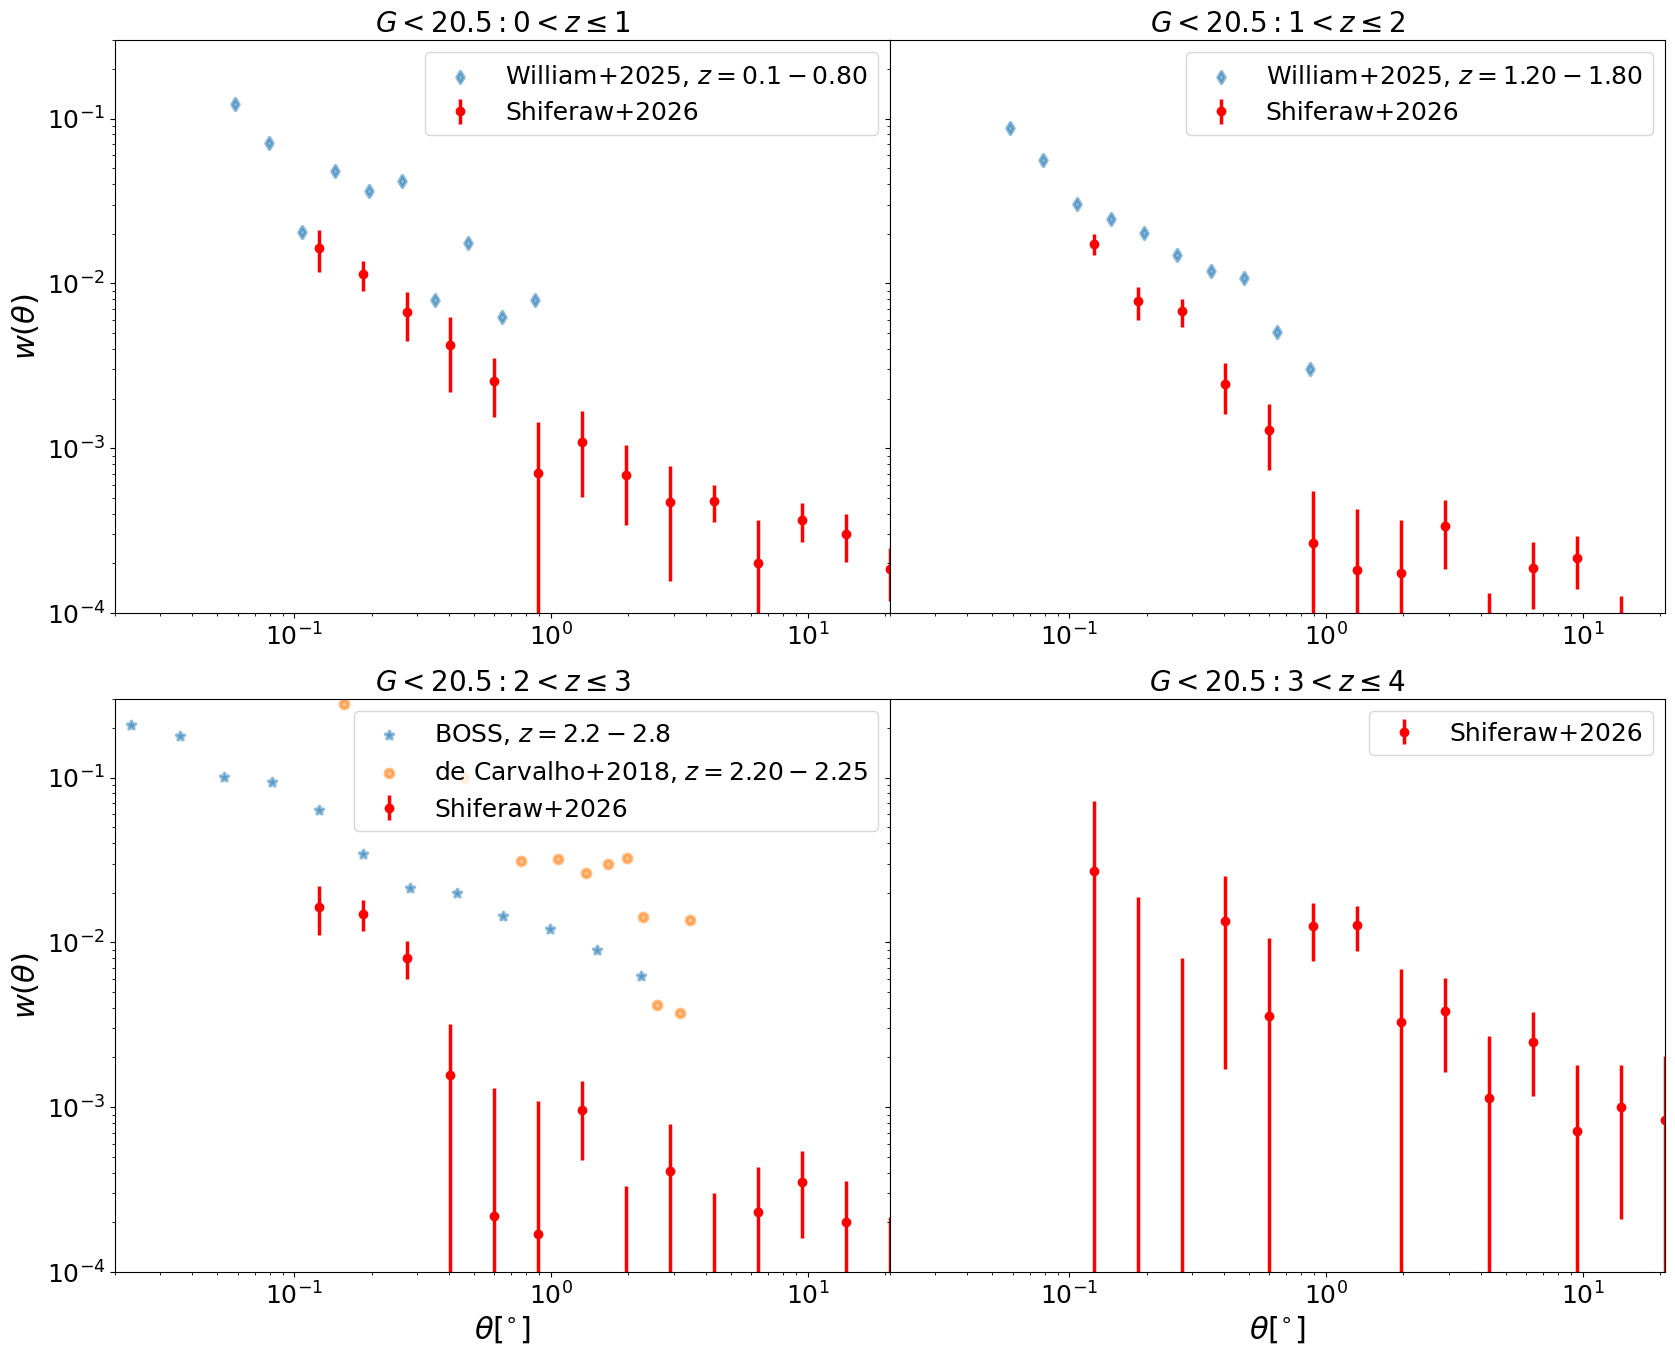

In [35]:
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2, hspace = 0.15, wspace = 0)
bbox_to_anchor = [(-0.45, 0.7),(1.3, 0.8), (0, 0), (0, 0)]

k = 0
for j in z_array:

    ax1 = fig.add_subplot(gs[j])
          
    C = np.load('../results/cov_w_theta_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N{}.npy'.format(G_hi, rmin, rmax, nbins, j, N))
    # C = np.zeros((nbins, nbins))
    # for cosmo, color in zip(cosmos, ['red', 'orange']):
    wp_zbin_percentile = np.load('../results/w_theta_G{}_rmin{}_rmax{}_nbins{}_z{:.1f}_N{}.npy'.format(G_hi, rmin, rmax, nbins, j, N))

    if len(wp_zbin_percentile) == nbins:
        ax1.errorbar(quaia.recenter(thetabins), wp_zbin_percentile, linewidth = 2.5, marker = 'o', 
                 label = r'Shiferaw+2026', color = 'red', yerr = np.sqrt(np.diag(C)), linestyle = 'None')
    else:
        ax1.errorbar(quaia.recenter(thetabins), wp_zbin_percentile[j], linewidth = 2.5, marker = 'o', 
                 label = r'Shiferaw+2026', color = 'red', yerr = np.sqrt(np.diag(C)), linestyle = 'None')
    if j == 0:
        ax1.scatter(william[j][0], william[j][1], linewidth = 2.5, marker = 'd', label = r'William+2025, $z = 0.1-0.80$', alpha = 0.5)
    elif j == 1:
        ax1.scatter(william[j][0], william[j][1], linewidth = 2.5, marker = 'd', label = r'William+2025, $z = 1.20-1.80$', alpha = 0.5)
    elif j == 2:
        ax1.scatter((boss[0]*u.arcmin).to(u.deg), boss[1], linewidth = 2.5, marker = '*', label = r'BOSS, $z = 2.2-2.8$', alpha = 0.5)
        ax1.scatter(carvalho[0], carvalho[1], linewidth = 2.5, label = r'de Carvalho+2018, $z = 2.20-2.25$', alpha = 0.5)
        # ax1.scatter(spies[0], spies[1], linewidth = 2.5, marker = 'd', label = r'SpIES+SHELA, $z = 2.2-2.8$', alpha = 0.5)
    # else:
    #     ax1.scatter((hsc[0]*u.arcmin).to(u.deg), hsc[1], linewidth = 2.5, marker = 'v', label = r'HSC, $z = 3-4$', alpha = 0.5)

    ax1.set_title('$G<{}: {:.0f}<z \leq{:.0f}$'.format(G_hi, j, j+1))
    ax1.set_yscale('log')
    ax1.set_xlim(2e-2, quaia.recenter(thetabins)[-1])
    ax1.set_ylim(1e-4, 3e-1)
    # ax1.set_xlim(2e-2, 3e1)
    # ax1.set_ylim(2e-5, 4e-1)
    ax1.legend()

    if (j) % 2 == 0:
        ax1.set_ylabel(r'$w(\theta)$')

    else:
        ax1.set_yticklabels([])

    # if scale == 'log':
    ax1.set_xscale('log')

    if j>1:
        ax1.set_xlabel(r'$\theta[^{\circ}]$')

plt.show()